In [1]:
pip install librosa soundfile audioread

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import warnings
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
speech_path = "../datasets/speech/Audio_Speech_Actors_01-24"

print("Dataset Exists :", os.path.exists(speech_path))

Dataset Exists : True


Emotion mapping

In [4]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "surprised"
}

Reading the dataset

In [5]:
audio_paths = []
emotions = []

for actor in sorted(os.listdir(speech_path)):

    actor_path = os.path.join(speech_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in sorted(os.listdir(actor_path)):

        if file.endswith(".wav"):

            emotion_code = file.split("-")[2]

            audio_paths.append(
                os.path.join(actor_path, file)
            )

            emotions.append(
                emotion_map[emotion_code]
            )

speech_df = pd.DataFrame({
    "Path": audio_paths,
    "Emotion": emotions
})

speech_df.head()

,Path,Emotion
0,../datasets/speech/Audio_Speech_Actors_01-24\A...,neutral
1,../datasets/speech/Audio_Speech_Actors_01-24\A...,neutral
2,../datasets/speech/Audio_Speech_Actors_01-24\A...,neutral
3,../datasets/speech/Audio_Speech_Actors_01-24\A...,neutral
4,../datasets/speech/Audio_Speech_Actors_01-24\A...,calm


Dataset Info

In [6]:
print("Total Audio Files :", len(speech_df))
print()

print(speech_df["Emotion"].value_counts())

Total Audio Files : 1440

Emotion
calm         192
happy        192
sad          192
angry        192
fear         192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


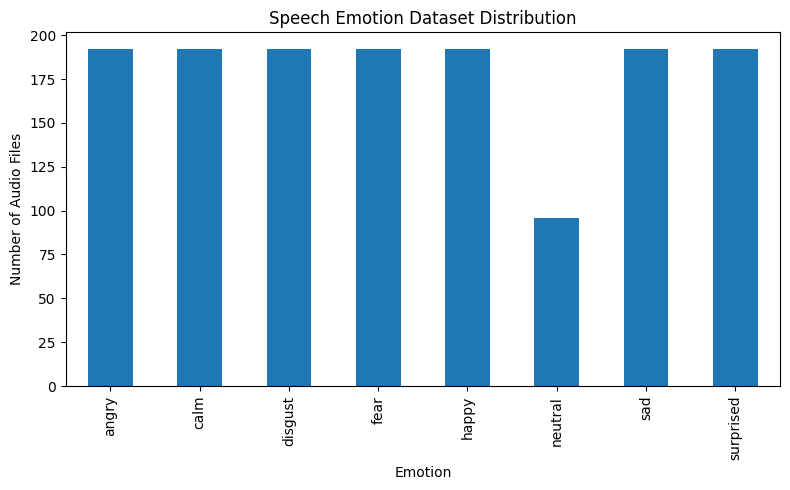

In [7]:
plt.figure(figsize=(8,5))

speech_df["Emotion"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Speech Emotion Dataset Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")

plt.tight_layout()

plt.savefig(
    "../reports/figures/speech_dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Audio Exploration & Feature Extraction

Loading the sample audio

In [8]:
sample_path = speech_df.iloc[0]["Path"]

signal, sample_rate = librosa.load(sample_path, sr=22050)

print("Sample Rate :", sample_rate)
print("Duration :", round(len(signal) / sample_rate, 2), "seconds")

Sample Rate : 22050
Duration : 3.3 seconds


Plotting the waveform

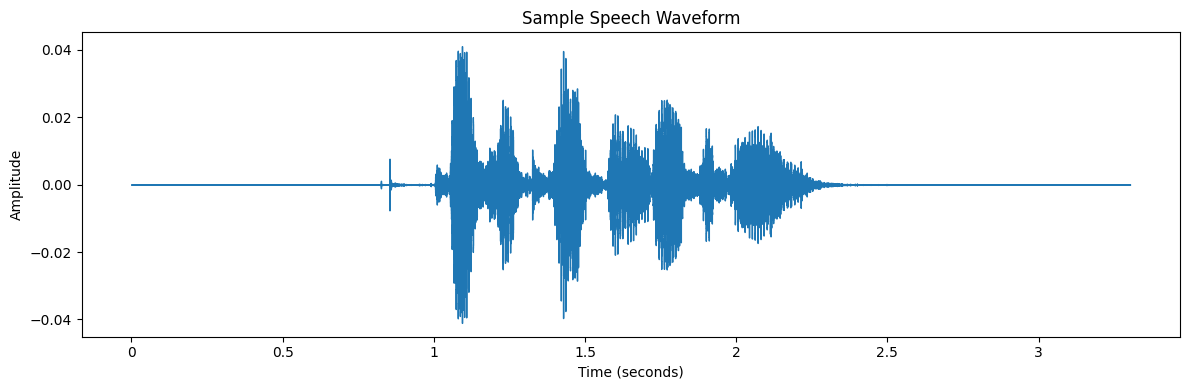

In [9]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(signal, sr=sample_rate)

plt.title("Sample Speech Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()

plt.savefig(
    "../reports/figures/sample_waveform.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Plot Spectrogram

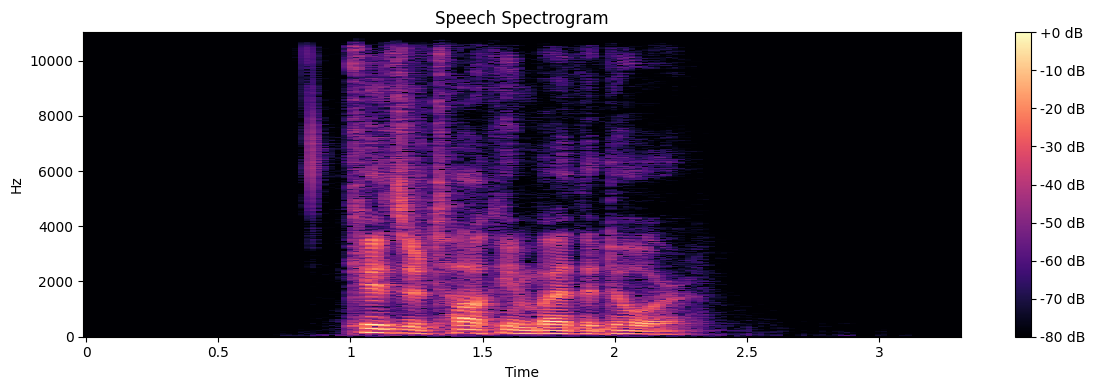

In [10]:
spectrogram = librosa.amplitude_to_db(
    np.abs(librosa.stft(signal)),
    ref=np.max
)

plt.figure(figsize=(12,4))

librosa.display.specshow(
    spectrogram,
    sr=sample_rate,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Speech Spectrogram")

plt.tight_layout()

plt.savefig(
    "../reports/figures/sample_spectrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# MFCC Feature Extraction

MFCC extraction function

In [11]:
def extract_features(file_path):

    signal, sample_rate = librosa.load(file_path, sr=22050)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=40
    )

    # Normalize each coefficient
    mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / (
        np.std(mfcc, axis=1, keepdims=True) + 1e-8
    )

    max_pad = 174

    if mfcc.shape[1] < max_pad:
        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, max_pad - mfcc.shape[1])),
            mode="constant"
        )
    else:
        mfcc = mfcc[:, :max_pad]

    return mfcc

In [12]:
features = extract_features(sample_path)

print(features.shape)

(40, 174)


visualizing the MFCC

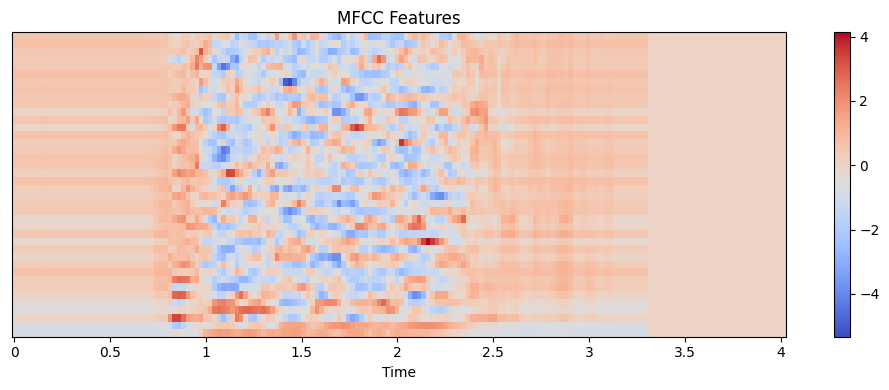

In [13]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    features,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC Features")

plt.tight_layout()

plt.savefig(
    "../reports/figures/sample_mfcc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Build the Training Dataset

extract features from all the files

In [14]:
from tqdm import tqdm

X = []
y = []

for _, row in tqdm(speech_df.iterrows(), total=len(speech_df)):

    features = extract_features(row["Path"])

    X.append(features)

    y.append(row["Emotion"])

100%|██████████| 1440/1440 [00:15<00:00, 93.10it/s] 


Converting to Numpy arrays

In [15]:
X = np.array(X)
y = np.array(y)

print("Feature Shape :", X.shape)
print("Label Shape :", y.shape)

Feature Shape : (1440, 40, 174)
Label Shape : (1440,)


Encoding labels

In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['angry' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprised']


In [17]:
import joblib


os.makedirs("../models/encoders", exist_ok=True)

joblib.dump(
    label_encoder,
    "../models/encoders/speech_label_encoder.pkl"
)

['../models/encoders/speech_label_encoder.pkl']

Train-test split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

Add CNN Channel Dimension

In [19]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(921, 40, 174, 1)
(231, 40, 174, 1)
(288, 40, 174, 1)


Training : (921, 40, 174, 1)

Validation : (231, 40, 174, 1)

Test : (288, 40, 174, 1)

saving

In [20]:
os.makedirs("../datasets/speech/processed", exist_ok=True)

np.save("../datasets/speech/processed/X_train.npy", X_train)
np.save("../datasets/speech/processed/X_val.npy", X_val)
np.save("../datasets/speech/processed/X_test.npy", X_test)

np.save("../datasets/speech/processed/y_train.npy", y_train)
np.save("../datasets/speech/processed/y_val.npy", y_val)
np.save("../datasets/speech/processed/y_test.npy", y_test)

# Build the Speech Emotion CNN

Build CNN architecture

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense,
    Input
)

speech_model = Sequential([

    Input(shape=(40,174,1)),

    Conv2D(32, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.40),

    Dense(8, activation="softmax")
])

speech_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 40, 174, 32)       320       
                                                                 
 batch_normalization (Batch  (None, 40, 174, 32)       128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 20, 87, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 20, 87, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 20, 87, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 20, 87, 64)        2

Compile

In [22]:
from tensorflow.keras.optimizers import Adam

speech_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Callbacks

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

lets Train

In [24]:
history = speech_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=30,

    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
29/29 [==============================] - 8s 235ms/step - loss: 3.4242 - accuracy: 0.1640 - val_loss: 2.5427 - val_accuracy: 0.1342 - lr: 5.0000e-04
Epoch 2/30
29/29 [==============================] - 6s 210ms/step - loss: 2.0293 - accuracy: 0.1737 - val_loss: 4.7350 - val_accuracy: 0.1255 - lr: 5.0000e-04
Epoch 3/30
29/29 [==============================] - 6s 211ms/step - loss: 1.9763 - accuracy: 0.2204 - val_loss: 5.9449 - val_accuracy: 0.1429 - lr: 5.0000e-04
Epoch 4/30
29/29 [==============================] - ETA: 0s - loss: 1.9520 - accuracy: 0.2345
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
29/29 [==============================] - 6s 218ms/step - loss: 1.9520 - accuracy: 0.2345 - val_loss: 6.5392 - val_accuracy: 0.1558 - lr: 5.0000e-04
Epoch 5/30
29/29 [==============================] - 6s 223ms/step - loss: 1.9303 - accuracy: 0.2400 - val_loss: 6.5450 - val_accuracy: 0.1558 - lr: 1.0000e-04
Epoch 6/30
29/29 [===========================

In [25]:
test_loss, test_acc = speech_model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)

9/9 [==============================] - 0s 40ms/step - loss: 2.5120 - accuracy: 0.1285
Test Loss : 2.51202130317688
Test Accuracy : 0.1284722238779068
